In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, RocCurveDisplay, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Цель анализа

Выявить паттерны оттока клиентов и сформулировать бизнес-рекомендации.

## Ключевые вопросы исследования:

- **Кто чаще уходит?** (сегментация клиентов)
- **Что влияет на отток?** (корреляции, оценка важности признаков)
- **Когда клиент "готов" уйти?** (построение предиктивной модели)
- **Что делать бизнесу?** (бизнес-рекомендации)

# EDA

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.columns = df.columns.str.lower()

In [7]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [8]:
df.groupby(['churn'])['churn'].count()

churn
No     5174
Yes    1869
Name: churn, dtype: int64

In [9]:
df['churn'].value_counts(normalize=True)

churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

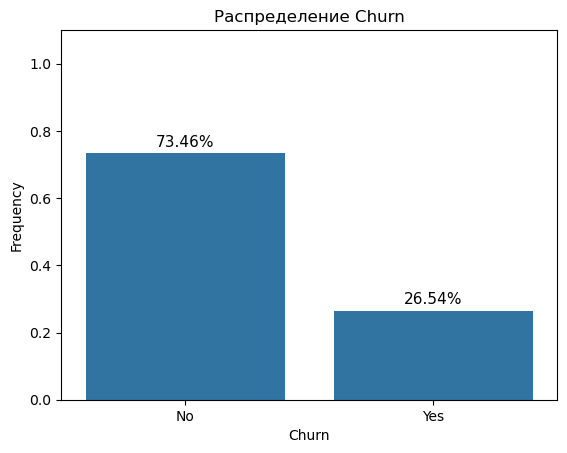

In [10]:
churn_counts = df['churn'].value_counts(normalize=True).sort_index()
ax = sns.barplot(x=churn_counts.index, y=churn_counts.values)

for i, (_, value) in enumerate(churn_counts.items()):
    ax.text(i, value + 0.01, f'{value:.2%}', 
            ha='center', va='bottom', fontsize=11)

plt.ylim(0, 1.1)
plt.xlabel('Churn')
plt.ylabel('Frequency')
plt.title('Распределение Churn')
plt.show()

In [11]:
churned = df[df['churn'] == 'Yes']
avg_monthly_churned = churned['monthlycharges'].mean()

annual_per_client = avg_monthly_churned * 12

churned_clients = len(churned) 

total_loss = churned_clients * annual_per_client

print(f"Средний чек ушедших: ${avg_monthly_churned:.2f}")
print(f"Годовая выручка на клиента: ${annual_per_client:.2f}")
print(f"Ушедших клиентов: {churned_clients}")
print(f"Годовые потери: ${total_loss:,.0f}")

Средний чек ушедших: $74.44
Годовая выручка на клиента: $893.30
Ушедших клиентов: 1869
Годовые потери: $1,669,570


Пропусков нет. Данные не сбалансированы. Клиенты распределены не равномерно по оттоку.

**Исследование признаков**

In [12]:
df['totalcharges'] = df['totalcharges'].str.strip().replace(' ', 0)
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

In [13]:
df['totalcharges'].isnull().sum()

11

In [14]:
df['totalcharges'] = df['totalcharges'].fillna(0)

In [15]:
cat_features = df.select_dtypes(include='object')

In [16]:
cat_features = cat_features.drop('churn', axis=1)

In [17]:
cat_features = cat_features.drop('customerid', axis=1)

In [18]:
num_features = df.select_dtypes(include=np.number)

**Признаки:** 
<span style="color: blue">seniorcitizen</span>, 
<span style="color: blue">tenure</span>, 
<span style="color: blue">monthlycharges</span>

<span style="color: green">**SENIORCITIZEN**</span>

In [19]:
df.groupby(['seniorcitizen'])['churn'].apply(lambda x: (x=='Yes').astype(int).mean()*100)

seniorcitizen
0    23.606168
1    41.681261
Name: churn, dtype: float64

In [20]:
df.groupby(['seniorcitizen'])['churn'].apply(lambda x: (x=='Yes').astype(int).count())

seniorcitizen
0    5901
1    1142
Name: churn, dtype: int64

In [21]:
df[df['churn'] == 'Yes']['seniorcitizen'].mean() * 100

25.468164794007492

In [22]:
# Годовые потери от пенсионеров
senior_churned = df[(df['seniorcitizen'] == 1) & (df['churn'] == 'Yes')]
len(senior_churned) * senior_churned['monthlycharges'].mean() * 12

461035.19999999995

Пенсионеры уходят чаще, но их меньшинство. Абсолютный ущерб меньше, чем от сегмента новых клиентов на месячных контрактах.

<span style="color: green">**TENURE**</span>

In [23]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39], dtype=int64)

In [24]:
df['tenure'].max()

72

In [25]:
df['tenure_group'] = pd.qcut(df['tenure'], q=5, 
                            labels=['1-14мес', '15-29мес', '30-44мес', '45-59мес', '60-72мес'])

In [26]:
df.groupby(['tenure_group'])['churn'].apply(lambda x: (x=='Yes').astype(int).mean()*100).sort_values(ascending=False)

C:\Windows\Temp\ipykernel_8828\2505507722.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['tenure_group'])['churn'].apply(lambda x: (x=='Yes').astype(int).mean()*100).sort_values(ascending=False)


tenure_group
1-14мес     52.937205
15-29мес    33.428776
30-44мес    22.372159
45-59мес    15.555556
60-72мес     6.609808
Name: churn, dtype: float64

Риск оттока монотонно падает с ростом tenure независимо от типа контракта.

<span style="color: green">**MONTHLYCHARGES**</span>

In [27]:
df['monthlycharges'].unique()

array([29.85, 56.95, 53.85, ..., 63.1 , 44.2 , 78.7 ])

In [28]:
df['monthly_group'] = pd.cut(df['monthlycharges'], 
                               bins=[0, 30, 60, 90, 150],
                               labels=['0-30$', '30-60$', '60-90$', '90-150$'])

In [29]:
df.groupby('monthly_group')['churn'].apply(lambda x: (x == 'Yes').mean()*100).sort_values(ascending=False)

C:\Windows\Temp\ipykernel_8828\1385456793.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('monthly_group')['churn'].apply(lambda x: (x == 'Yes').mean()*100).sort_values(ascending=False)


monthly_group
60-90$     33.906119
90-150$    32.777458
30-60$     25.928854
0-30$       9.800363
Name: churn, dtype: float64

<span style="color: green">**TOTALCHARGES**</span>

In [30]:
df['totalcharges'].max()

8684.8

In [31]:
df['totalcharges'].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: totalcharges, dtype: float64

In [32]:
df['totalcharges'].quantile([0.25, 0.5, 0.75, 0.9, 0.95])

0.25     398.550
0.50    1394.550
0.75    3786.600
0.90    5973.690
0.95    6921.025
Name: totalcharges, dtype: float64

In [33]:
df['totalcharges_group'] = pd.cut(df['totalcharges'],
                           bins=[0, 1395, 3790, 5974, 7000, 10000],
                           labels=['0-1395$', '1395-3790$', '3790-5974$', '5974-7000$', '7000$+'])

In [34]:
df.groupby('totalcharges_group')['churn'].apply(lambda x: (x == 'Yes').mean()*100).sort_values(ascending=False)

C:\Windows\Temp\ipykernel_8828\308883106.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('totalcharges_group')['churn'].apply(lambda x: (x == 'Yes').mean()*100).sort_values(ascending=False)


totalcharges_group
0-1395$       34.434634
1395-3790$    22.998296
3790-5974$    15.829384
5974-7000$    14.550265
7000$+        10.091743
Name: churn, dtype: float64

**Категориальные признаки**

In [35]:
cat_features.head(3)

,gender,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check


In [36]:
cat_features.columns

Index(['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines',
       'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection',
       'techsupport', 'streamingtv', 'streamingmovies', 'contract',
       'paperlessbilling', 'paymentmethod'],
      dtype='object')

In [37]:
importance = {}

for col in cat_features.columns.to_list():
    churn_cat = df.groupby(col)['churn'].apply(lambda x: (x=='Yes').mean())
    importance[col] = churn_cat.max() - churn_cat.min()

sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

In [38]:
for col, diff in sorted_importance[:10]:
    print(f'{col}: разница {diff}')

contract: разница 0.39877819012275195
internetservice: разница 0.3448778451712098
onlinesecurity: разница 0.3436174350143538
techsupport: разница 0.3423049331314137
onlinebackup: разница 0.32523776135923776
deviceprotection: разница 0.3172264486117845
paymentmethod: разница 0.3004231107950205
streamingmovies: разница 0.2627545053895259
streamingtv: разница 0.2611815133183771
paperlessbilling: разница 0.17235008738544225


**Рассмотрим взаимосвязь признаков подробнее**

<span style="color: green">**TENURE**</span>

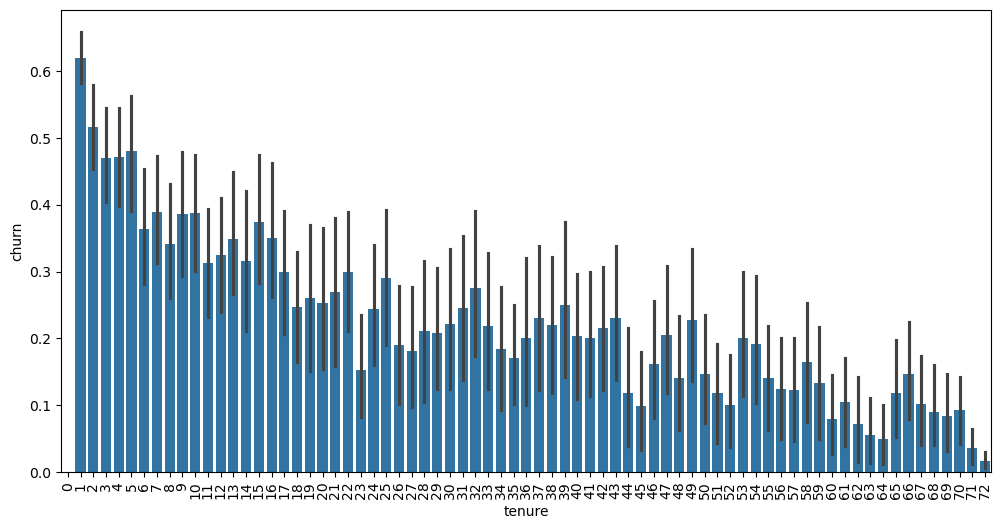

In [39]:
plt.figure(figsize=(12, 6))
sns.barplot(df, 
            x='tenure', 
            y=(df['churn'] == 'Yes').astype(int),
            order=sorted(df['tenure'].unique()))
plt.xticks(rotation=90)
plt.show()

Клиенты ухолят после пробного периода подписки (1-2 мес.)

Гипотеза: отток из-за отсутствия клиентской поддержки

<span style="color: green">**MONTHLYCHARGES & TOTALCHARGES**</span>

In [40]:
df[['customerid','tenure', 'monthlycharges', 'totalcharges']].head(10)

,customerid,tenure,monthlycharges,totalcharges
0,7590-VHVEG,1,29.85,29.85
1,5575-GNVDE,34,56.95,1889.50
2,3668-QPYBK,2,53.85,108.15
3,7795-CFOCW,45,42.30,1840.75
4,9237-HQITU,2,70.70,151.65
5,9305-CDSKC,8,99.65,820.50
6,1452-KIOVK,22,89.10,1949.40
7,6713-OKOMC,10,29.75,301.90
8,7892-POOKP,28,104.80,3046.05
9,6388-TABGU,62,56.15,3487.95


In [41]:
# Проверим какой признак сильнее коррелирует с churn?
from scipy.stats import pointbiserialr

churn_binary = (df['churn'] == 'Yes').astype(int)

print("monthlycharges:", pointbiserialr(churn_binary, df['monthlycharges']))
print("totalcharges:", pointbiserialr(churn_binary, df['totalcharges']))

monthlycharges: SignificanceResult(statistic=0.19335642223784705, pvalue=2.706645606888192e-60)
totalcharges: SignificanceResult(statistic=-0.19832426260399555, pvalue=2.1272116132395556e-63)


Если клиент платит около 100$/мес и TotalCharges небольшой, то клиент новый и дорогой -достаточно большой риск оттока.

Еслик клиент платит около 100$/мес и TotalCharges большой, то клиент страый и дорогой - риск оттока меньше. 

В паре признаки более информативны. Оставим два признака.

Создадим новый признак — avg_monthly = totalcharges / tenure и проверим менял ли клиент тариф. Если он сильно отличается от MonthlyCharges, значит клиент менял тариф.

In [42]:
df['avg_monthly'] = df['totalcharges'] / df['tenure']

In [43]:
df['avg_monthly'].head()

0    29.850000
1    55.573529
2    54.075000
3    40.905556
4    75.825000
Name: avg_monthly, dtype: float64

In [44]:
df['tariff_change'] = df['monthlycharges'].round(2) - df['avg_monthly'].round(2)

In [45]:
df['tariff_change'].describe()

count    7032.000000
mean       -0.001182
std         2.616122
min       -18.900000
25%        -1.160000
50%         0.000000
75%         1.150000
max        19.120000
Name: tariff_change, dtype: float64

Большинство клиентов не меняли тариф (или меняли давно, и среднее совпало)

Но есть группа с резким повышением тарифа (+19$) — возможно, акция закончилась

И группа с понижением (-18$) — возможно, перешли на дешевле

In [46]:
(df[df['tariff_change'] > 10]['churn'] == 'Yes').mean()*100

69.56521739130434

In [47]:
(df[df['tariff_change'] > 10]['churn'] == 'Yes').sum()

16

In [48]:
# Общее количество клиентов с повышением > 10$
total = df[df['tariff_change'] > 10].shape[0]
churned = (df[df['tariff_change'] > 10]['churn'] == 'Yes').sum()

print(f"Всего клиентов: {total}")
print(f"Ушедших: {churned}")
print(f"Отток: {churned/total*100:.1f}%")

Всего клиентов: 23
Ушедших: 16
Отток: 69.6%


<span style="color: green">**CONTRACT**</span>

In [49]:
df.groupby('contract')['churn'].apply(lambda x: (x=='Yes').mean()*100)

contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: churn, dtype: float64

Contract: размах 40% - это много.\
Стоит рассмотреть этот признак подробне.

In [50]:
df.loc[df['churn'] == 'Yes'].groupby(['tenure_group'])['monthlycharges'].sum()

C:\Windows\Temp\ipykernel_8828\3445162031.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.loc[df['churn'] == 'Yes'].groupby(['tenure_group'])['monthlycharges'].sum()


tenure_group
1-14мес     49896.10
15-29мес    35662.40
30-44мес    26116.25
45-59мес    18405.55
60-72мес     9050.55
Name: monthlycharges, dtype: float64

Инсайт: Компания теряет больше всего денег на новых клиентах.

In [51]:
df[df['contract'] == 'Month-to-month'].groupby('tenure_group')['churn'].apply(lambda x: (x=='Yes').mean()*100)

C:\Windows\Temp\ipykernel_8828\1711402053.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['contract'] == 'Month-to-month'].groupby('tenure_group')['churn'].apply(lambda x: (x=='Yes').mean()*100)


tenure_group
1-14мес     55.201699
15-29мес    40.633484
30-44мес    33.578431
45-59мес    29.561201
60-72мес    22.222222
Name: churn, dtype: float64

<span style="color: green">**ONLINESECURITY_INTERNETSERVICE_TECHSUPPORT**</span>

Проверим влияние услуг на отток у клиентов, у которые есть подключение к интернету.

In [52]:
# Базовые коммуникации
basic = ['phoneservice', 'multiplelines']

# Защитные функции
protection = ['onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport']

# Развлекательные 
entertainment = ['streamingtv', 'streamingmovies']

df['basic_count'] = df[basic].apply(lambda x: (x == 'Yes').sum(), axis=1)
df['protection_count'] = df[protection].apply(lambda x: (x == 'Yes').sum(), axis=1)
df['entertainment_count'] = df[entertainment].apply(lambda x: (x == 'Yes').sum(), axis=1)

df_internet = df[df['internetservice'] != 'No']

for col in ['basic_count', 'protection_count', 'entertainment_count']:
    print(f"\n{col}:")
    print(df_internet.groupby(col)['churn'].apply(lambda x: (x=='Yes').mean()*100))


basic_count:
basic_count
0    24.926686
1    33.816863
2    31.951312
Name: churn, dtype: float64

protection_count:
protection_count
0    56.669298
1    38.854806
2    23.760933
3    12.433581
4     5.319149
Name: churn, dtype: float64

entertainment_count:
entertainment_count
0    34.440040
1    31.430404
2    29.432990
Name: churn, dtype: float64


Проверим как количество, подключенных услуг, влияет на отток.

In [53]:
service_cols = ['phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 
       'techsupport', 'streamingtv', 'streamingmovies']

for col in service_cols:
    print(f"\n{col}: {df[col].unique()}")


phoneservice: ['No' 'Yes']

multiplelines: ['No phone service' 'No' 'Yes']

internetservice: ['DSL' 'Fiber optic' 'No']

onlinesecurity: ['No' 'Yes' 'No internet service']

onlinebackup: ['Yes' 'No' 'No internet service']

deviceprotection: ['No' 'Yes' 'No internet service']

techsupport: ['No' 'Yes' 'No internet service']

streamingtv: ['No' 'Yes' 'No internet service']

streamingmovies: ['No' 'Yes' 'No internet service']


In [54]:
df_services = df[service_cols].copy()

In [55]:
df_services['phoneservice'] = (df_services['phoneservice'] == 'Yes').astype(int)

df_services['multiplelines'] = df_services['multiplelines'].map({
    'Yes': 1,
    'No': 0,
    'No phone service':0
})

df_services['internetservice'] = df_services['internetservice'].map({
    'DSL': 1,
    'Fiber optic': 1,
    'No': 0
})

internet_services = ['onlinesecurity', 'onlinebackup', 'deviceprotection', 
                     'techsupport', 'streamingtv', 'streamingmovies']

for col in internet_services:
    df_services[col] = (df_services[col] == 'Yes').astype(int)

In [56]:
df['service_count'] = df_services.sum(axis=1)

In [57]:
df['service_count'].value_counts().sort_index()

service_count
1    1264
2     859
3     846
4     965
5     922
6     908
7     676
8     395
9     208
Name: count, dtype: int64

In [58]:
churn_by_service = df.groupby('service_count')['churn'].apply(lambda x: (x == 'Yes').mean() * 100)
churn_by_service

service_count
1    10.917722
2    30.966240
3    44.917258
4    36.476684
5    31.344902
6    25.550661
7    22.485207
8    12.405063
9     5.288462
Name: churn, dtype: float64

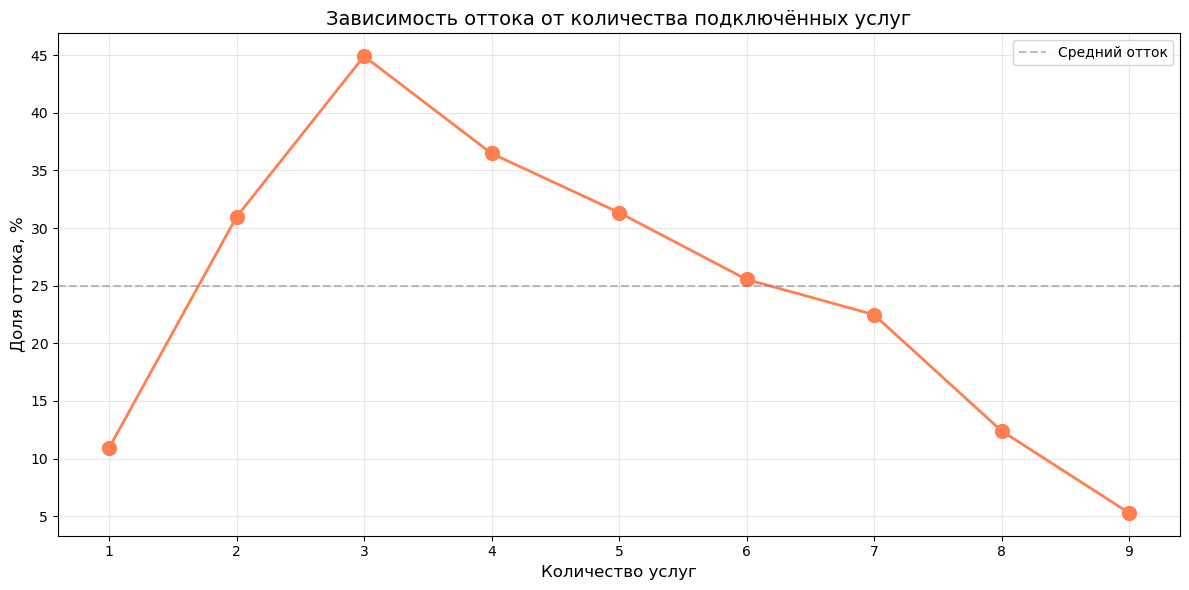

In [59]:
plt.figure(figsize=(12, 6))

plt.plot(churn_by_service.index, churn_by_service.values, 
         marker='o', linewidth=2, markersize=10, color='coral')
        
plt.axhline(y=25, color='gray', linestyle='--', alpha=0.5, label='Средний отток')
plt.xlabel('Количество услуг', fontsize=12)
plt.ylabel('Доля оттока, %', fontsize=12)
plt.title('Зависимость оттока от количества подключённых услуг', fontsize=14)
plt.xticks(range(1, 10))
plt.grid(True, alpha=0.3)
plt.legend()

#plt.text(1.5, 45, '', fontsize=9, color='red')

plt.tight_layout()
plt.show()

In [60]:
df_internet = df[
    (df['internetservice'] != 'No') & 
    (df['service_count'] == 2)
]

for col in ['basic_count', 'protection_count', 'entertainment_count']:
    print(f"\n{col}:")
    print(df_internet.groupby(col)['churn'].apply(lambda x: (x=='Yes').mean()*100))


basic_count:
basic_count
0    42.105263
1    51.612903
Name: churn, dtype: float64

protection_count:
protection_count
0    52.655889
1    33.333333
Name: churn, dtype: float64

entertainment_count:
entertainment_count
0    48.459959
1    66.666667
Name: churn, dtype: float64


In [61]:
df_internet = df[
    (df['internetservice'] != 'No') & 
    (df['service_count'] == 3)
]

for col in ['basic_count', 'protection_count', 'entertainment_count']:
    print(f"\n{col}:")
    print(df_internet.groupby(col)['churn'].apply(lambda x: (x=='Yes').mean()*100))


basic_count:
basic_count
0    27.083333
1    45.121951
2    56.666667
Name: churn, dtype: float64

protection_count:
protection_count
0    58.476658
1    36.438356
2    12.162162
Name: churn, dtype: float64

entertainment_count:
entertainment_count
0    40.166667
1    57.333333
2    47.619048
Name: churn, dtype: float64


In [62]:
df_internet = df[
    (df['internetservice'] != 'No') & 
    (df['service_count'] == 4)
]

for col in ['basic_count', 'protection_count', 'entertainment_count']:
    print(f"\n{col}:")
    print(df_internet.groupby(col)['churn'].apply(lambda x: (x=='Yes').mean()*100))


basic_count:
basic_count
0    19.736842
1    33.112583
2    47.777778
Name: churn, dtype: float64

protection_count:
protection_count
0    61.206897
1    35.529412
2    21.235521
3     8.163265
Name: churn, dtype: float64

entertainment_count:
entertainment_count
0    27.253219
1    43.989071
2    48.120301
Name: churn, dtype: float64


Клиенты, у которых подключеена услуги защиты, менее подвержены оттоку.

In [63]:
pd.crosstab(
    [df_internet['service_count'], df_internet['protection_count']], 
    df_internet['churn'], 
    normalize='index'
) * 100

churn                                  No        Yes
service_count protection_count                      
4             0                 38.793103  61.206897
              1                 64.470588  35.529412
              2                 78.764479  21.235521
              3                 91.836735   8.163265

# MODELING

In [64]:
df_m = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [65]:
df_m.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [66]:
df_m.columns = df_m.columns.str.lower()

In [67]:
df_m.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

Преобразуем тип атрибута totalcharges и заполним пропуски.

In [68]:
df_m['totalcharges'].dtype

dtype('O')

In [69]:
df_m['totalcharges'] = pd.to_numeric(df_m['totalcharges'], errors='coerce')

In [70]:
df_m['totalcharges'].dtype

dtype('float64')

In [71]:
df_m['totalcharges'].isna().sum()

11

In [72]:
df_m['totalcharges'] = df_m['totalcharges'].fillna(df_m['totalcharges'].median())

Дисбаланс классов

In [73]:
df_m.groupby('churn')['churn'].count()

churn
No     5174
Yes    1869
Name: churn, dtype: int64

In [74]:
df_m['churn'].value_counts(normalize=True)*100

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Удалим customerID - не имеет ценности для модели

In [75]:
df_m = df_m.drop('customerid', axis=1)

Разделим целевую переменную и остальные признаки

In [76]:
df_m['churn'] = (df_m['churn'] == 'Yes').astype(int)

In [77]:
y = df_m['churn']
X = df_m.drop('churn', axis=1)

In [78]:
numeric_features = ['tenure', 'monthlycharges', 'totalcharges']
categorical_features = df_m.drop('churn', axis=1).loc[:,~df_m.drop('churn', axis=1).columns.isin(numeric_features)].columns

Разделим выборку на Train / Test

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y #сохраняем пропорцию churn
)

In [80]:
print("Train:", X_train.shape, "Churn rate:", y_train.mean())
print("Test: ", X_test.shape,  "Churn rate:", y_test.mean())

Train: (5634, 19) Churn rate: 0.2653532126375577
Test:  (1409, 19) Churn rate: 0.2654364797728886


Препроцессинг

In [81]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler() ,numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

In [82]:
X_train_processed = preprocessor.fit_transform(X_train)

In [83]:
X_test_processed = preprocessor.transform(X_test)

**Выбор метрик для оценки модели**

Поскольку в данных наблюдаем дисбаланс, используем параметр class_weight='balanced' - помогает сбалансировать данные.

Метрики для оценки: 
Accuracy — не подходит, т.к. есть дисбаланс и всегда будет предсказывать большой % клиентов, которые не уйдут.\
ROC-AUC — хорошо подходит для ранжирования, показывает на сколько хорошо модель умеет разделять ушедших клиентов от лояльных.\
Recall — из всех ушедших, сколько мы нашли.\
Precision — из тех, кого определили как ушедших, сколько действительно ушло.

**Logistic Regression (Baseline)**

In [84]:
logreg = LogisticRegression(max_iter=1000,
                           class_weight='balanced',
                           random_state=42)

In [85]:
logreg.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [86]:
y_pred = logreg.predict(X_test_processed)
y_prob = logreg.predict_proba(X_test_processed)[:, 1]

In [87]:
print(classification_report(y_test, y_pred))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


ROC-AUC: 0.841

Confusion Matrix:
[[746 289]
 [ 81 293]]


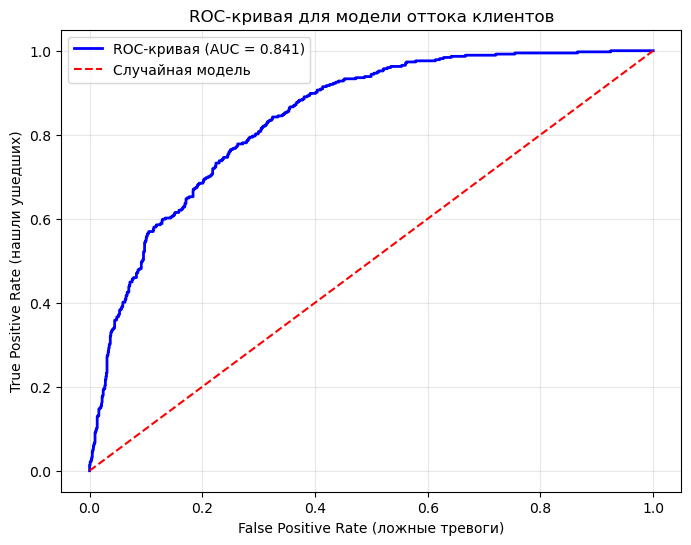

In [88]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC-кривая (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Случайная модель')
plt.xlabel('False Positive Rate (ложные тревоги)')
plt.ylabel('True Positive Rate (нашли ушедших)')
plt.title('ROC-кривая для модели оттока клиентов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

recall: 0.78 - хороший результат, нашли 78% ушедших\
precision: 0.5 - не очень хорошо, только половина ложных предсказаний\
f1-score: 0.61 - баланс между recall и  precision 61%, модель ошибается в 39% случаев при принятии решений.\
ROC-AUC: 0.841 - модель хорошо разделяет классы

Модель чувствительна, но при этом удерживает критическую массу уходящих клиентов.

**Random Forest**

In [89]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

In [90]:
rf.fit(X_train_processed, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [91]:
y_pred_rf = rf.predict(X_test_processed)
y_prob_rf = rf.predict_proba(X_test_processed)[:,1]

In [92]:
print(classification_report(y_test, y_pred_rf))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")

              precision    recall  f1-score   support

           0       0.89      0.79      0.83      1035
           1       0.55      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409


ROC-AUC: 0.839


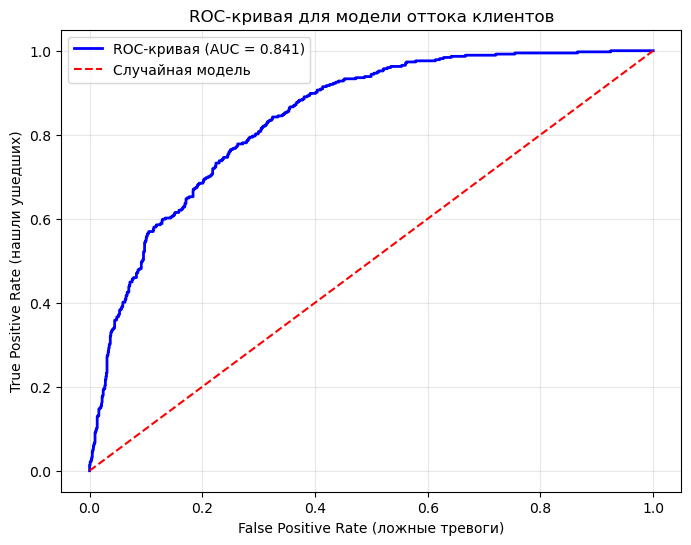

In [93]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, 'b-', linewidth=2, label=f'ROC-кривая (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Случайная модель')
plt.xlabel('False Positive Rate (ложные тревоги)')
plt.ylabel('True Positive Rate (нашли ушедших)')
plt.title('ROC-кривая для модели оттока клиентов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Модель "случайный лес" практически не отличается ои логистической регрессии.\
Но ключевая метрика precision выше, в данному случае точность предсказания клиентов, которые уйдут важнее.

In [94]:
importances = rf.feature_importances_
feature_names = (numeric_features + 
                 list(preprocessor.named_transformers_['cat']
                     .get_feature_names_out(categorical_features)))

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print("\nTop 10 features:")
print(feat_imp.head(10))


Top 10 features:
tenure                            0.126756
contract_Month-to-month           0.106454
totalcharges                      0.103194
monthlycharges                    0.077880
contract_Two year                 0.059004
onlinesecurity_No                 0.049725
techsupport_No                    0.046458
internetservice_Fiber optic       0.039097
paymentmethod_Electronic check    0.033850
contract_One year                 0.023636
dtype: float64


9 из 10 ключевых признаков совпадает с теми, что определи при EDA.\
Модель показала еще один ключевой paymentmethod_Electronic check, рассмотрим его подробнее.

In [96]:
df_m.groupby(['paymentmethod'])['churn'].mean()*100

paymentmethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: churn, dtype: float64

Electronic check - почти половина уходит - клиент каждый месяц активно платит, помнит о расходе, каждый раз может обдумывать о продлении подписки.\
Предположительно если первести клиентов на автоплатеж, это можнет снизить риск оттока до 15%.

# Общий вывод

В ходе анализа по выявлению оттока определили ключевые артибуты которые влияют на отток клиентов:

tenure\
monthlycharges\
totalcharges\
contract\
internetservice\
onlinesecurity\
techsupport\
electronic_check

Также выявили два ключевых сегмента.

**Сегмент 1**  - продолжительность работы с клиентом + срок соглашения (подписки)

In [97]:
# Клиенты в зоне риска (ещё не ушёл, но есть риск)
risk = df.loc[                   
    (df['tenure'] <= 12) &
    (df['contract'] == 'Month-to-month')
]
risk.head(2)

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,churn,tenure_group,monthly_group,totalcharges_group,avg_monthly,tariff_change,basic_count,protection_count,entertainment_count,service_count
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,1-14мес,0-30$,0-1395$,29.850,0.00,0,1,0,2
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,1-14мес,30-60$,0-1395$,54.075,-0.23,1,2,0,4


In [98]:
# Количество клиентов в выборке "зона риска"
numbers_of_clients = len(risk)
numbers_of_clients

1994

In [99]:
# Средний чек
AOV = round(risk['monthlycharges'].mean(),2)
AOV

58.22

In [100]:
# Выручка в зоне риска
revenue_at_risk = round(numbers_of_clients * AOV * 12,2)
revenue_at_risk

1393088.16

In [101]:
# Доля ушедших
current_churn = (risk['churn'] == 'Yes').mean()
current_churn = round(current_churn,4)
current_churn

0.5135

In [102]:
# Рассчитываем потенциальные потери
potential_loss_of_revenue = numbers_of_clients * current_churn * AOV * 12
potential_loss_of_revenue = round(potential_loss_of_revenue, 2)
potential_loss_of_revenue

715350.77

In [103]:
# Если снизить отток с 51% до 25% (например, через контракты и сопровождение (поддержка клиента))
target_churn = 0.25
revenue_saved = round(potential_loss_of_revenue - (numbers_of_clients * target_churn * AOV * 12),2)
revenue_saved

367078.73

In [104]:
# Варианты исхода
schemas = {
    'Пессимистичный': 0.35,
    'Реалистичный': 0.25,
    'Оптимистичный': 0.15
}

for name, target in schemas.items():
    result = round(potential_loss_of_revenue - (numbers_of_clients * target * AOV * 12),2)
    print(f"{name}: {result:,.0f}")

Пессимистичный: 227,770
Реалистичный: 367,079
Оптимистичный: 506,388


**Сегмент 2** - есть интернет, но мало защиты

In [105]:
# 
risk2 = df[(df['internetservice'] != 'No') & (df['protection_count'] < 2)]

clients = len(risk2)
current_churn = (risk2['churn'] == 'Yes').mean()
target_churn = 0.20  # реалистично: с 50% до 20%
avg_monthly = risk2['monthlycharges'].mean()

saved = clients * (current_churn - target_churn)
revenue = saved * avg_monthly * 12

print(f"Клиентов: {clients}")
print(f"Сохраним: {saved:.0f}")
print(f"Выручка: ${revenue:,.0f}")

Клиентов: 2734
Сохраним: 741
Выручка: $631,455


In [106]:
# Сегмент 1: новые клиенты
seg1 = df[(df['contract'] == 'Month-to-month') & (df['tenure'] <= 12)]

# Сегмент 2: мало защиты
seg2 = df[(df['internetservice'] != 'No') & (df['protection_count'] < 2)]

# Пересечение
overlap = df[
    (df['internetservice'] != 'No') & 
    (df['protection_count'] < 2) &
    (df['contract'] == 'Month-to-month') & 
    (df['tenure'] <= 12)
]

print(f"Сегмент 1 (контракты): {len(seg1)}")
print(f"Сегмент 2 (защита): {len(seg2)}")
print(f"Пересечение: {len(overlap)}")
print(f"Уникальных клиентов всего: {len(seg1) + len(seg2) - len(overlap)}")

Сегмент 1 (контракты): 1994
Сегмент 2 (защита): 2734
Пересечение: 1358
Уникальных клиентов всего: 3370


In [128]:
# Общая выручка
merge = pd.concat([seg1, seg2]).drop_duplicates()

clients_m = len(merge)
current_churn_m = (merge['churn'] == 'Yes').mean()
target_churn_m = 0.20 
avg_monthly_m = merge['monthlycharges'].mean()

saved_m = clients_m * (current_churn_m - target_churn_m)
revenue_m = saved_m * avg_monthly_m * 12

print(f"Клиентов: {clients_m}")
print(f"Сохраним: {saved_m:.0f}")
print(f"Выручка: ${revenue_m:,.0f}")

Клиентов: 3370
Сохраним: 814
Выручка: $637,154


**Рекомендации**

1. Пакет «Защита» — предложение клиентам дополнительного пакета услуг со скидкой.\
Целевой сегмент: клиенты без подключённых дополнительных сервисов с высоким риском оттока.\
Предполагаемое снижение оттока с 53% до 20%.
Это максимальный эффект среди всех сегментов, однако требуется отдельная оценка стоимости скидки и влияния на маржинальность.
3. Перевод клиентов на годовые контракты — предложение бонуса или скидки за переход.\
Целевой сегмент: новые клиенты, клиенты с подпсикой на месяц-два и высоким риском оттока.\
Предполагаемое снижение оттока с 51% до 25%.
5. Перевод на автоплатеж.\
Целевой сегмент: клиенты с оплатой Electronic check независимо от текущего уровня риска оттока.\
Предполагаемое снижение оттока с 45% до 15%.

Представленные показатели снижения оттока рассчитаны для каждого сегмента в отдельности и не подлежат прямому суммированию при комбинированном применении. Пересечение целевых сегментов и взаимное влияние мер удержания учтены в итоговом расчёте экономического эффекта.